<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/Literature%20Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Literature Review**

**Source 1: Kaggle: Industrial Safety & Health Analytics Database (IHM Stefanini). Dataset page and schema. (Kaggle)**

12 different plants in 03 different countries

Accident level:

      I = not severe
      VI = very sever




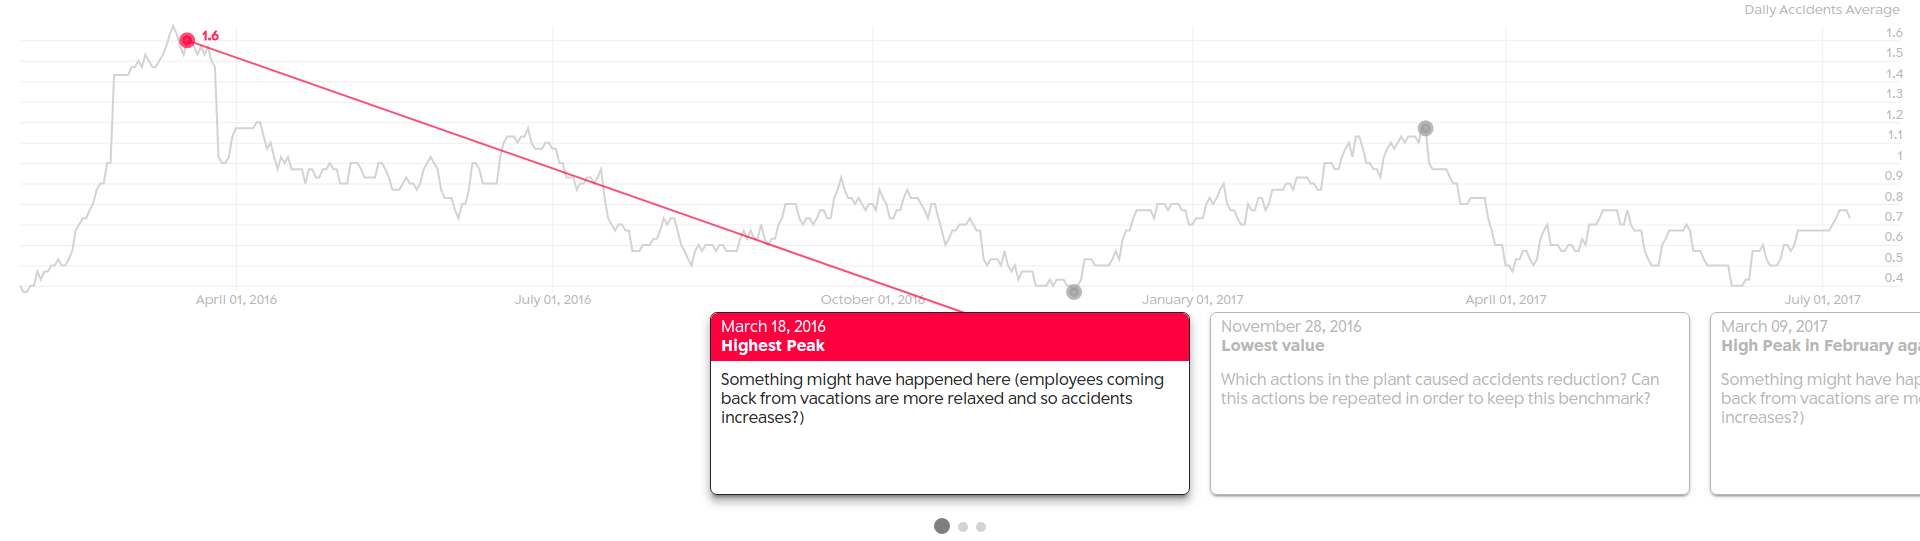

The above imae show a prior analysis cqarried out using the steffeni's data set and few predictions and analytical results obtained. this analysis is based on the date of accidents.

**Source 2: Community example: “Industrial Safety & Health Analytics — EDA” (Kaggle notebook). (Kaggle)**

Mainly EDA: Exploratory Data Analysis (a method to understand data patterns) has done in this article to understand different kinds of pattern throghout the the data set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

data_set_1 = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database.csv")
data_set_2 = pd.read_csv("https://raw.githubusercontent.com/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/main/IHMStefanini_industrial_safety_and_health_database_with_accidents_description.csv")

In [2]:
data_set_1.info() #summary of the variables and data set 1

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Data                      439 non-null    object
 1   Countries                 439 non-null    object
 2   Local                     439 non-null    object
 3   Industry Sector           439 non-null    object
 4   Accident Level            439 non-null    object
 5   Potential Accident Level  439 non-null    object
 6   Genre                     439 non-null    object
 7   Employee ou Terceiro      439 non-null    object
 8   Risco Critico             439 non-null    object
dtypes: object(9)
memory usage: 31.0+ KB


In [3]:
data_set_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                425 non-null    int64  
 1   Data                      425 non-null    object 
 2   Countries                 425 non-null    object 
 3   Local                     425 non-null    object 
 4   Industry Sector           425 non-null    object 
 5   Accident Level            425 non-null    object 
 6   Potential Accident Level  425 non-null    object 
 7   Genre                     425 non-null    object 
 8   Employee or Third Party   425 non-null    object 
 9   Critical Risk             425 non-null    object 
 10  Description               425 non-null    object 
 11  Unnamed: 11               0 non-null      float64
dtypes: float64(1), int64(1), object(10)
memory usage: 40.0+ KB


In [5]:
data_set_1.head() #to go through what kind of data is recorded normally

,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee ou Terceiro,Risco Critico
0,1/1/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed
1,1/2/2016 0:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems
2,1/6/2016 0:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools
3,1/8/2016 0:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others
4,1/10/2016 0:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others


In [6]:
data_set_2.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,0,1/1/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,1,1/2/2016 0:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2,1/6/2016 0:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,3,1/8/2016 0:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,4,1/10/2016 0:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


Here, i have found out that all the coloumn names do not exactly represent the type the record it is holding. hence, a renaming is requred.

    Data                    --->  Date
    Genre                   --->  Gender
    Employee ou Terceiro    --->  Employee or Third party
    Risco Critico           --->  Critical Risk

In [7]:
data_set_1.rename(columns={"Genre": "Gender", "Data": "Date","Employee ou Terceiro":"Employee or Third party","Risco Critico":"Critical Risk"}, inplace=True)
data_set_1['Date']= pd.to_datetime(data_set_1['Date'])

In [8]:
data_set_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      439 non-null    datetime64[ns]
 1   Countries                 439 non-null    object        
 2   Local                     439 non-null    object        
 3   Industry Sector           439 non-null    object        
 4   Accident Level            439 non-null    object        
 5   Potential Accident Level  439 non-null    object        
 6   Gender                    439 non-null    object        
 7   Employee or Third party   439 non-null    object        
 8   Critical Risk             439 non-null    object        
dtypes: datetime64[ns](1), object(8)
memory usage: 31.0+ KB


In [9]:
data_set_2.head()

,Unnamed: 0,Data,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Genre,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,0,1/1/2016 0:00,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,1,1/2/2016 0:00,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2,1/6/2016 0:00,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,3,1/8/2016 0:00,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,4,1/10/2016 0:00,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


Here, i have also found out that all the coloumn names do not exactly represent the type the record it is holding in data set 2. hence, a renaming is requred.

    Data                    --->  Date
    Genre                   --->  Gender

In [10]:
data_set_2.rename(columns={"Genre": "Gender", "Data": "Date"}, inplace=True)
data_set_2['Date']= pd.to_datetime(data_set_2['Date'])
#data_set_2.drop(labels="Unnamed: 11",axis=1,inplace=True)
data_set_2.drop(labels="Unnamed: 0",axis=1,inplace=True)

In [11]:
data_set_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      425 non-null    datetime64[ns]
 1   Countries                 425 non-null    object        
 2   Local                     425 non-null    object        
 3   Industry Sector           425 non-null    object        
 4   Accident Level            425 non-null    object        
 5   Potential Accident Level  425 non-null    object        
 6   Gender                    425 non-null    object        
 7   Employee or Third Party   425 non-null    object        
 8   Critical Risk             425 non-null    object        
 9   Description               425 non-null    object        
 10  Unnamed: 11               0 non-null      float64       
dtypes: datetime64[ns](1), float64(1), object(9)
memory usage: 36.7+ KB


In [13]:
data_set_2.head()

,Date,Countries,Local,Industry Sector,Accident Level,Potential Accident Level,Gender,Employee or Third Party,Critical Risk,Description,Unnamed: 11
0,2016-01-01,Country_01,Local_01,Mining,I,IV,Male,Third Party,Pressed,While removing the drill rod of the Jumbo 08 f...,NaN
1,2016-01-02,Country_02,Local_02,Mining,I,IV,Male,Employee,Pressurized Systems,During the activation of a sodium sulphide pum...,NaN
2,2016-01-06,Country_01,Local_03,Mining,I,III,Male,Third Party (Remote),Manual Tools,In the sub-station MILPO located at level +170...,NaN
3,2016-01-08,Country_01,Local_04,Mining,I,I,Male,Third Party,Others,Being 9:45 am. approximately in the Nv. 1880 C...,NaN
4,2016-01-10,Country_01,Local_04,Mining,IV,IV,Male,Third Party,Others,Approximately at 11:45 a.m. in circumstances t...,NaN


In [12]:
data_set_2["Accident Level"].value_counts()

,count
Accident Level,
I,316
II,40
III,31
IV,30
V,8


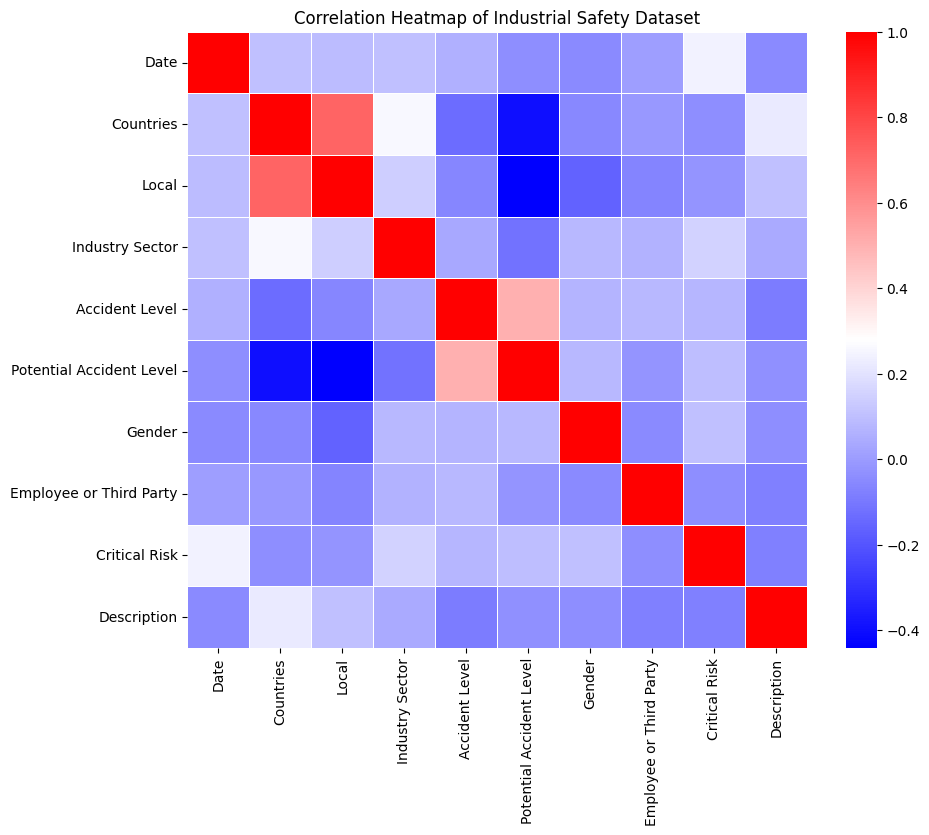

In [ ]:
data_encoded = data_set_2.copy()

for col in data_encoded.columns:
    data_encoded[col] = data_encoded[col].astype('category').cat.codes

corr_matrix = data_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="bwr",       # blue-white-red like your image
    annot=False,      # no numbers inside
    linewidths=0.5
)
plt.title("Correlation Heatmap of Industrial Safety Dataset")
plt.show()


Now let's generate few gaphs and see how each variables are variying with others

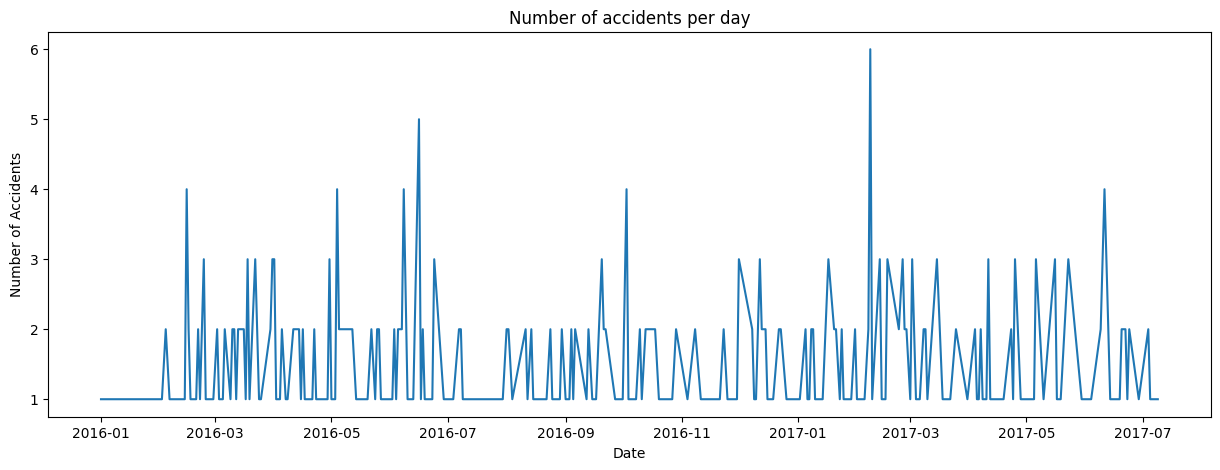

In [ ]:
f, axes = plt.subplots(1,1,figsize=(15,5))
sns.lineplot(x=data_set_2['Date'].value_counts().index, y=data_set_2['Date'].value_counts().values, ax=axes)
axes.set_title("Number of accidents per day")
plt.xlabel("Date")
plt.ylabel("Number of Accidents")
plt.show()

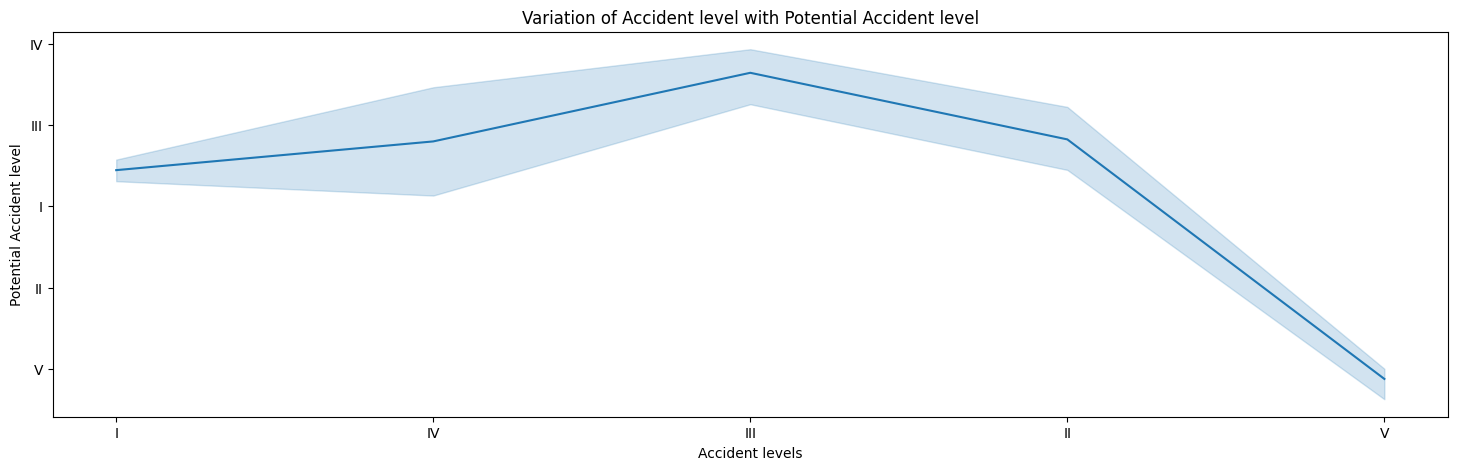

In [ ]:
f, axes = plt.subplots(1,1,figsize=(18,5))
sns.lineplot(x=data_set_2['Accident Level'], y=data_set_2['Potential Accident Level'])
axes.set_title("Variation of Accident level with Potential Accident level")
plt.xlabel("Accident levels")
plt.ylabel("Potential Accident level")
plt.show()

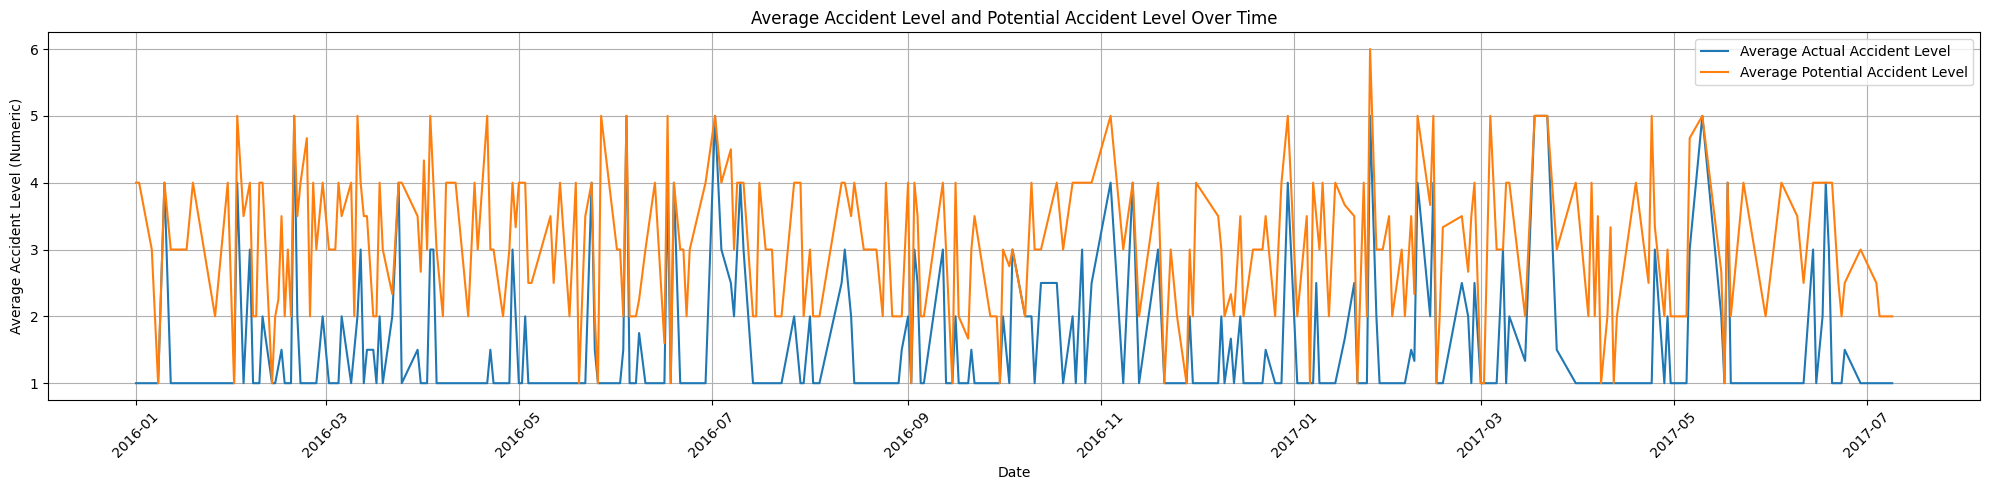

In [ ]:
# Reuse the level_mapping created earlier
level_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6}

# Create a copy of the dataframe to add numerical columns
df_time_plot = data_set_2.copy()

# Ensure the 'Data' column is renamed to 'Date' and converted to datetime
df_time_plot.rename(columns={"Data": "Date"}, inplace=True)
df_time_plot['Date']= pd.to_datetime(df_time_plot['Date'])

# Convert 'Accident Level' and 'Potential Accident Level' to numerical
df_time_plot['Accident_Level_Numeric'] = df_time_plot['Accident Level'].map(level_mapping)
df_time_plot['Potential_Accident_Level_Numeric'] = df_time_plot['Potential Accident Level'].map(level_mapping)

# Group by Date and calculate the mean of the numerical accident levels
daily_avg_levels = df_time_plot.groupby('Date')[['Accident_Level_Numeric', 'Potential_Accident_Level_Numeric']].mean().reset_index()

plt.figure(figsize=(20, 5))

sns.lineplot(x='Date', y='Accident_Level_Numeric', data=daily_avg_levels, label='Average Actual Accident Level')
sns.lineplot(x='Date', y='Potential_Accident_Level_Numeric', data=daily_avg_levels, label='Average Potential Accident Level')

plt.title('Average Accident Level and Potential Accident Level Over Time')
plt.xlabel('Date')
plt.ylabel('Average Accident Level (Numeric)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Source 3: Lipianina-Honcharenko, K. et al. “Intelligent Method for Classifying the Level of Anthropogenic Disasters,” Big Data and Cognitive Computing, 2023. (MDPI)**

It is important to have accurate and timely information to assess the level of danger and take appropriate measures to eliminate disasters. Therefore, the purpose of the paper is to develop an effective method for assessing the level of anthropogenic disasters based on information from witnesses to the event

The main characteristics of the intelligent method for classifying the level of anthropogenic disasters are considered, in particular, exploratory data analysis using the EDA method, classification based on textual data using SMOTE, and data classification by the ensemble method of machine learning using boosting

*   Has a mobile application
*   Various methods exist for detecting anthropogenic accidents and disasters, such as visual observation, the use of sensors and monitors, data analysis from third-party sources
*   **However, most of these methods are limited in accuracy and response speed**
*   Disaster assessment based on social media data is one of the new directions in risk prediction and management research (insufficient accuracy and reliability of social media data, possibility of spreading false information)
*   According to [4], a distributed multi-tier emergency alerting system is developed using sensor-based event detectors, supporting applications for smart cities. This system can detect and deliver real-time emergency alarms based on detected events, pre-known risk levels of specific areas, and temporal information------------------------------------> (new source)
*   in [7] **Support Vector Machine (SVM), K-Nearest Neighbors (KNN), and logistic regression, data analysis algorithms, RoBERTa model[9]** were used
*   In [11], recent developments in the field of machine learning, for disaster management are analyzed, focusing on methods and applications such as prediction, risk assessment, hazard detection, early warning systems, monitoring, damage assessment, and post-disaster response, along with recommendations for further research------------------------------------> (new source)
*   Civique [12] is considering the another emergency detection system that primarily targets geotagged tweets and uses **Support Vector Machines (SVM) and Naive Bayes for training**

*   In [16], a hybrid ALBERT-based TextCNN-Hatt model is developed, utilizing topic knowledge for analyzing public sentiments during emergencies, demonstrating the high effectiveness with significant improvements in sentiment detection compared to previous models, and achieving an average accuracy of 89%, AUC of 94%, and CQI of 88%. This model keeps the practical potential for emergency response tasks and aiding decision-makers in responding appropriately to crisis situations. In [17], a hybrid structure was demonstrated including a pre-trained DistilBERT model and a proposed feature selection algorithm for emergency detection. Experiments and comparisons of the proposed system show its advantage in terms of event identification accuracy and feature reduction compared to others.


boosting methods
1. Gradient Boost
2. XGBoost
3. CatBoost

Exploratory Analysis?

The accident data was then processed and prepared using the Exploratory Data Analysis approach [25,26] for further use of the developed method. The following steps were performed (see Figure 1 Block 2):
Reading the data from the file and converting it to a format suitable for further processing.
Cleaning and normalizing the data, including removing unnecessary information and standardizing the format of records.
Creating a database to store the processed data and building an appropriate interface for accessing this data

**Their method in stages are shown in the paper under sub topic 3.**

SMOTE technique?




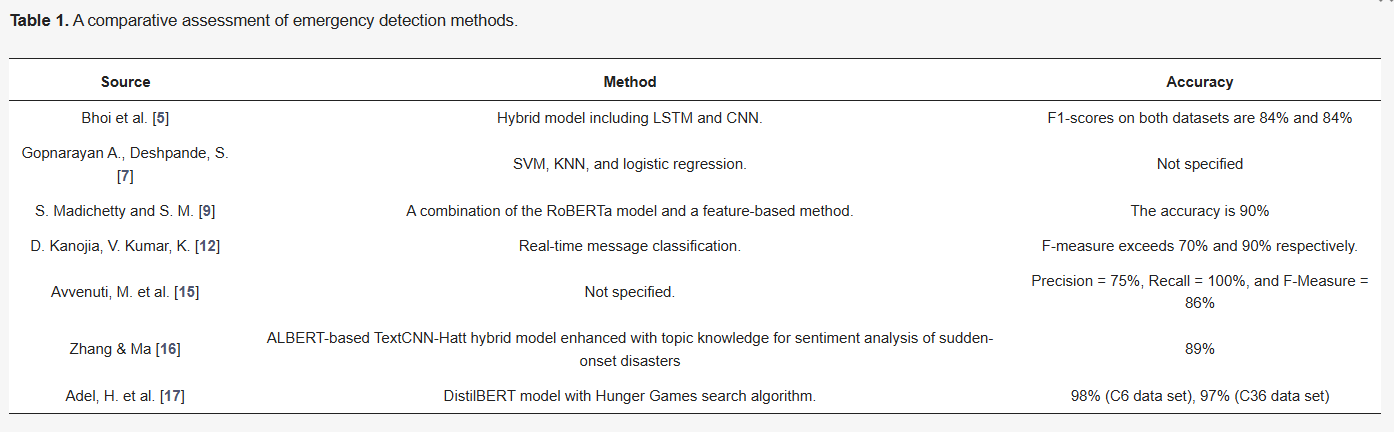

*   **Moreover, in existing works, insufficient attention is paid to assessing the consequences of these disasters and determining the level of danger**





1—Data collection

2—Exploratory data analysis

3—Classification of textual data

4—Classification of quantitative data

5—Display of estimates

6—Display of results 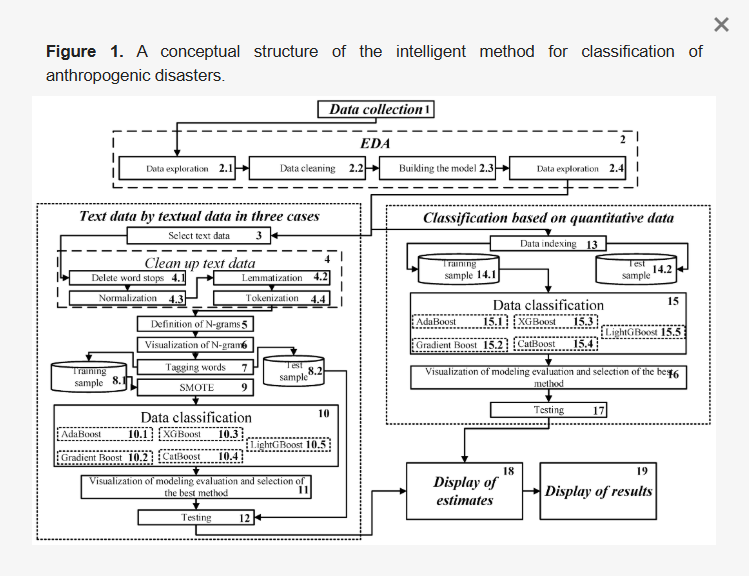

Cleaning the textual data (Block 4) [27,28]. It involves several sub steps:

**removal of stop words (4.1), normalization (4.2), lemmatization (4.3), and tokenization (4.4)**

Part-of-speech tagging (POS)


**Source 4:**

SMOTE

LSTM Networks

Video

1. visuallly evaluate
2. Correlation matrix
3. lae lanuage model?

